# Постановка задач

Имеется пуассоновский поток сетевых сообщений разного вида, которые обрабатывает маршрутизатор. Считаем что каждый вид сообщения равновероятен. Какие-то виды сообщений приоритетнее, чем другие. Входной поток на порядки превосходит скорость обработки пакетов - какие-то пакеты придется отклонить, какие-то обработать. Маршрутизатор не может ни в каком виде хранить и/или буфферизировать сообщения из-за ограничений памяти и из-за того, что данные в пакетах очень быстро теряют свою актуальность. Необходимо разработать вероятностный алгоритм принятия и отклонения пакетов так, чтобы средний приоритет сообщений в выходном канале был максимален, но при этом все


In [13]:
import math
import numpy as np
import matplotlib.pyplot as plt


In [14]:
def analytic_metrics(lam, class_probs, accept_probs, weights, capacity, min_delivery):
    p = np.array(class_probs, dtype=float)
    a = np.array(accept_probs, dtype=float)
    w = np.array(weights, dtype=float)
    p = p / p.sum()

    admitted = lam * p * a
    total_admitted = admitted.sum()

    feasible_min = np.all(admitted >= np.array(min_delivery, dtype=float) - 1e-12)
    feasible_cap = total_admitted <= capacity + 1e-12
    feasible_monotone = np.all(a[:-1] >= a[1:] - 1e-12)

    if total_admitted > 1e-12:
        mean_priority = float((admitted * w).sum() / total_admitted)
    else:
        mean_priority = 0.0

    utilization = min(total_admitted / capacity, 1.0) if capacity > 0 else 0.0

    return {
        "admitted_by_class": admitted,
        "total_admitted": total_admitted,
        "mean_priority": mean_priority,
        "utilization": utilization,
        "feasible": bool(feasible_min and feasible_cap and feasible_monotone),
        "feasible_min": bool(feasible_min),
        "feasible_cap": bool(feasible_cap),
        "feasible_monotone": bool(feasible_monotone),
    }


In [15]:
def simulate_router(num_slots, lam, class_probs, accept_probs, weights, capacity, seed=42):
    rng = np.random.default_rng(seed)
    p = np.array(class_probs, dtype=float)
    a = np.array(accept_probs, dtype=float)
    w = np.array(weights, dtype=float)
    p = p / p.sum()
    n = len(p)

    arrived_by_class = np.zeros(n, dtype=int)
    admitted_by_class = np.zeros(n, dtype=int)
    sent_by_class = np.zeros(n, dtype=int)
    dropped_by_class = np.zeros(n, dtype=int)

    channel_used_total = 0
    priority_sum_out = 0.0
    slot_loads = []

    for _ in range(num_slots):
        k = rng.poisson(lam)
        if k == 0:
            slot_loads.append(0)
            continue

        cls = rng.choice(n, size=k, p=p)
        arrived_by_class += np.bincount(cls, minlength=n)

        keep = rng.random(k) < a[cls]
        admitted = cls[keep]
        admitted_by_class += np.bincount(admitted, minlength=n)

        sent = np.zeros(n, dtype=int)
        rem = capacity
        for i in range(n):
            if rem <= 0:
                break
            take = min(np.count_nonzero(admitted == i), rem)
            sent[i] = take
            rem -= take

        sent_by_class += sent
        dropped_by_class += np.bincount(cls, minlength=n) - sent
        used = sent.sum()
        channel_used_total += used
        slot_loads.append(used)

        if used > 0:
            priority_sum_out += (sent * w).sum()

    total_sent = sent_by_class.sum()
    total_arrived = arrived_by_class.sum()

    delivery_ratio = np.divide(
        sent_by_class,
        arrived_by_class,
        out=np.zeros_like(sent_by_class, dtype=float),
        where=arrived_by_class > 0
    )

    drop_ratio = np.divide(
        dropped_by_class,
        arrived_by_class,
        out=np.zeros_like(dropped_by_class, dtype=float),
        where=arrived_by_class > 0
    )

    return {
        "arrived_by_class": arrived_by_class,
        "admitted_by_class": admitted_by_class,
        "sent_by_class": sent_by_class,
        "dropped_by_class": dropped_by_class,
        "delivery_ratio": delivery_ratio,
        "drop_ratio": drop_ratio,
        "utilization": channel_used_total / (num_slots * capacity),
        "mean_priority_out": priority_sum_out / total_sent if total_sent > 0 else 0.0,
        "total_arrived": total_arrived,
        "total_sent": total_sent,
        "slot_loads": np.array(slot_loads),
    }


In [16]:
def branch_and_bound(lam, class_probs, weights, capacity, min_delivery, levels):
    p = np.array(class_probs, dtype=float)
    p = p / p.sum()
    w = np.array(weights, dtype=float)
    L = np.array(min_delivery, dtype=float)
    levels = sorted(levels, reverse=True)

    n = len(p)

    best_a = None
    best_value = -1.0
    best_metrics = None

    nodes_visited = 0
    nodes_pruned = 0

    history_nodes = []
    history_best = []
    history_bound = []

    min_required_level = []
    for i in range(n):
        req = L[i] / (lam * p[i]) if lam * p[i] > 0 else math.inf
        feasible = [lv for lv in levels if lv + 1e-12 >= req]
        if not feasible:
            min_required_level.append(None)
        else:
            min_required_level.append(min(feasible))

    def feasible_tail_exists(partial):
        k = len(partial)
        prev = 1.0 if k == 0 else partial[-1]

        tail = []
        for j in range(k, n):
            need = min_required_level[j]
            if need is None:
                return False
            if need > prev + 1e-12:
                return False
            tail.append(need)
            prev = need

        full = np.array(partial + tail, dtype=float)
        total_admitted = lam * np.sum(p * full)
        return total_admitted <= capacity + 1e-12

    def optimistic_bound(partial):
        k = len(partial)
        if not feasible_tail_exists(partial):
            return -1.0

        prev = 1.0 if k == 0 else partial[-1]
        a = partial[:]

        for j in range(k, n):
            candidates = [lv for lv in levels if lv <= prev + 1e-12]
            candidates = sorted(candidates, reverse=True)

            chosen = None
            for lv in candidates:
                trial = np.array(a + [lv], dtype=float)

                rest = []
                prev2 = lv
                ok = True
                for t in range(j + 1, n):
                    need = min_required_level[t]
                    if need is None or need > prev2 + 1e-12:
                        ok = False
                        break
                    rest.append(need)
                    prev2 = need
                if not ok:
                    continue

                full = np.concatenate([trial, np.array(rest, dtype=float)])
                total_admitted = lam * np.sum(p * full)
                if total_admitted <= capacity + 1e-12:
                    chosen = lv
                    break

            if chosen is None:
                return -1.0

            a.append(chosen)
            prev = chosen

        m = analytic_metrics(lam, p, a, w, capacity, L)
        return m["mean_priority"] if m["feasible"] else -1.0

    def dfs(partial):
        nonlocal best_a, best_value, best_metrics, nodes_visited, nodes_pruned

        nodes_visited += 1

        ub = optimistic_bound(partial)
        history_nodes.append(nodes_visited)
        history_bound.append(max(ub, 0.0))
        history_best.append(max(best_value, 0.0))

        if ub <= best_value + 1e-12:
            nodes_pruned += 1
            return

        k = len(partial)
        if k == n:
            m = analytic_metrics(lam, p, partial, w, capacity, L)
            if m["feasible"] and m["mean_priority"] > best_value:
                best_a = np.array(partial, dtype=float)
                best_value = m["mean_priority"]
                best_metrics = m
                history_best[-1] = best_value
            return

        prev = 1.0 if k == 0 else partial[-1]
        need = min_required_level[k]
        if need is None:
            return

        candidates = [lv for lv in levels if lv <= prev + 1e-12 and lv + 1e-12 >= need]
        candidates = sorted(candidates, reverse=True)

        for lv in candidates:
            partial2 = partial + [lv]
            if not feasible_tail_exists(partial2):
                continue
            dfs(partial2)

    dfs([])

    return {
        "best_a": best_a,
        "best_value": best_value,
        "best_metrics": best_metrics,
        "nodes_visited": nodes_visited,
        "nodes_pruned": nodes_pruned,
        "history_nodes": np.array(history_nodes),
        "history_best": np.array(history_best),
        "history_bound": np.array(history_bound),
    }


best_a = [0.75 0.5  0.25 0.25 0.25]
nodes_visited = 7
nodes_pruned = 1
analytic_mean_priority = 2.8203
analytic_utilization = 0.96
sim_mean_priority_out = 3.0132
sim_utilization = 0.855


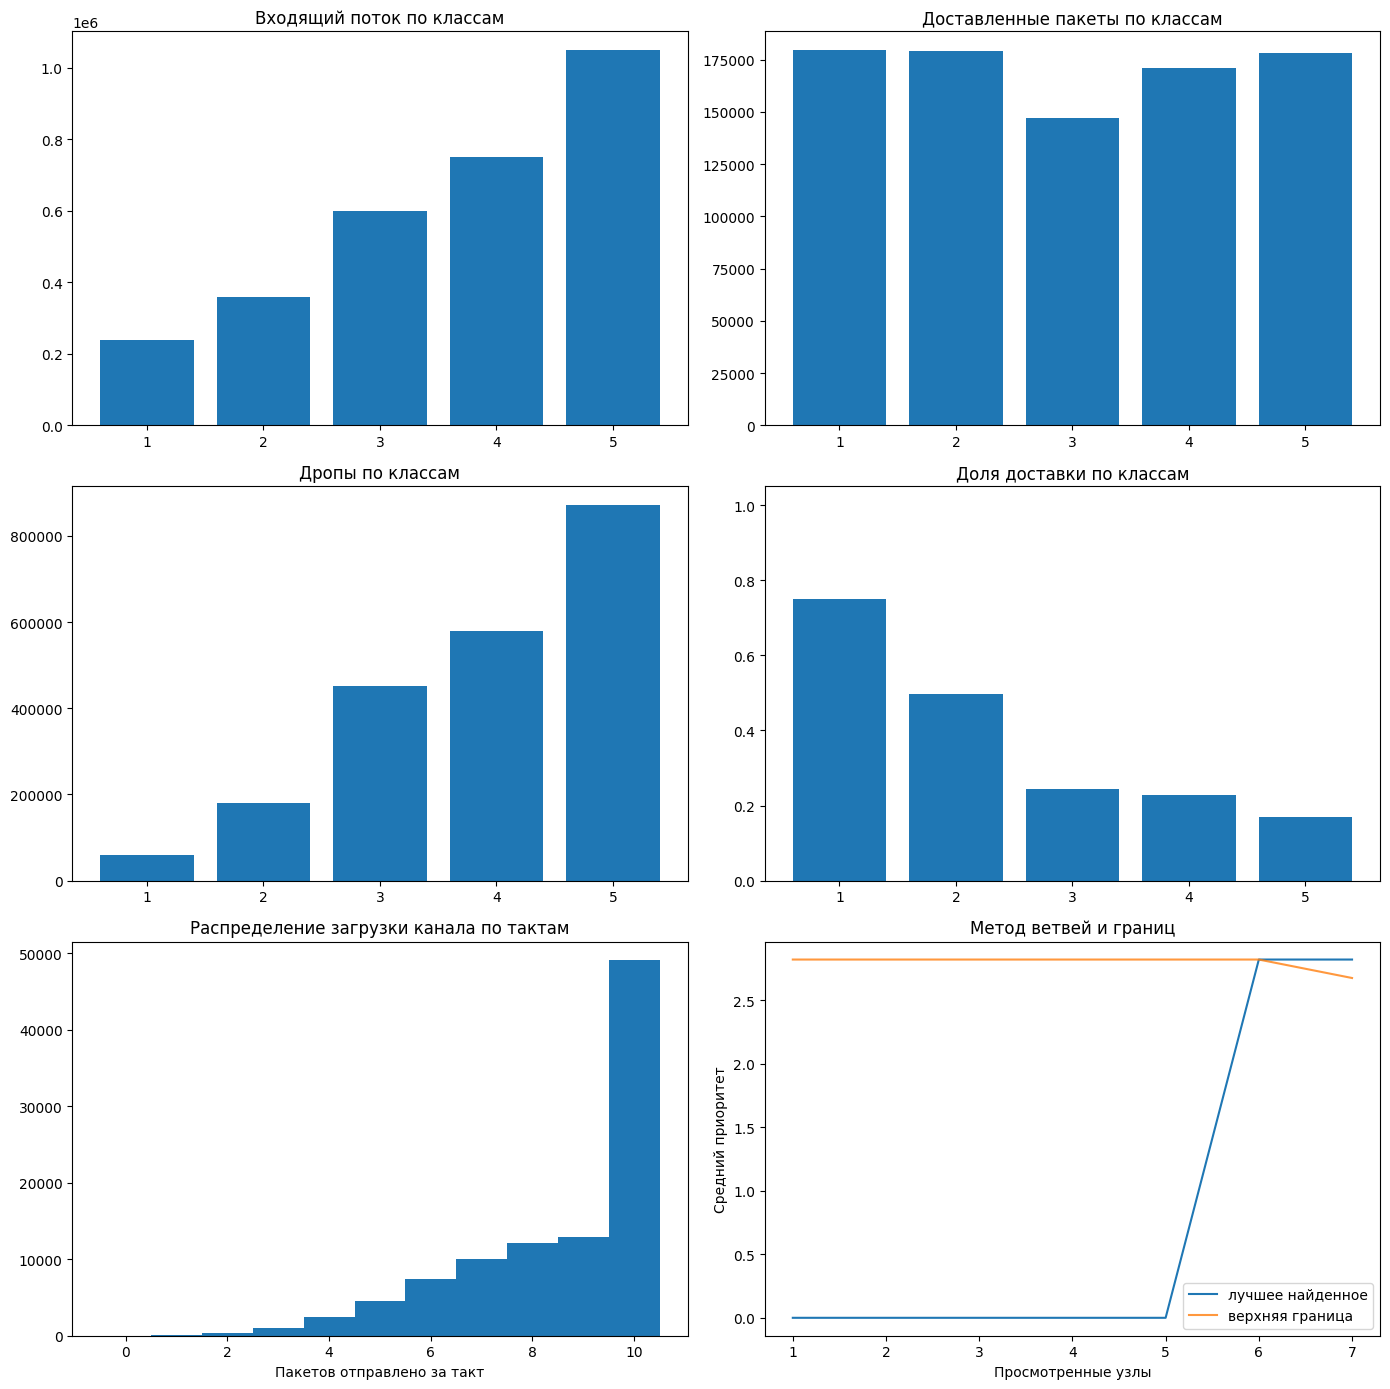

In [17]:
N = 5
lam = 30
capacity = 10

class_probs = [0.08, 0.12, 0.20, 0.25, 0.35]
weights = [5, 4, 3, 2, 1]
min_delivery = [1.0, 1.0, 1.0, 0.8, 0.5]
levels = [0.0, 0.25, 0.5, 0.75, 1.0]

bnb = branch_and_bound(
    lam=lam,
    class_probs=class_probs,
    weights=weights,
    capacity=capacity,
    min_delivery=min_delivery,
    levels=levels
)

best_a = bnb["best_a"]

print("best_a =", best_a)
# print("best_mean_priority =", round(bnb["best_mean_priority"], 4))
# print("best_utilization =", round(bnb["best_utilization"], 4))
# print("best_total_admitted =", round(bnb["best_total_admitted"], 4))
print("nodes_visited =", bnb["nodes_visited"])
print("nodes_pruned =", bnb["nodes_pruned"])

analytic = analytic_metrics(
    lam=lam,
    class_probs=class_probs,
    accept_probs=best_a,
    weights=weights,
    capacity=capacity,
    min_delivery=min_delivery
)

sim = simulate_router(
    num_slots=100000,
    lam=lam,
    class_probs=class_probs,
    accept_probs=best_a,
    weights=weights,
    capacity=capacity,
    seed=42
)

print("analytic_mean_priority =", round(analytic["mean_priority"], 4))
print("analytic_utilization =", round(analytic["utilization"], 4))
print("sim_mean_priority_out =", round(sim["mean_priority_out"], 4))
print("sim_utilization =", round(sim["utilization"], 4))

labels = [f"{i+1}" for i in range(N)]
x = np.arange(len(labels))

fig, axs = plt.subplots(3, 2, figsize=(14, 14))

axs[0, 0].bar(x, sim["arrived_by_class"])
axs[0, 0].set_title("Входящий поток по классам")
axs[0, 0].set_xticks(x, labels)

axs[0, 1].bar(x, sim["sent_by_class"])
axs[0, 1].set_title("Доставленные пакеты по классам")
axs[0, 1].set_xticks(x, labels)

axs[1, 0].bar(x, sim["dropped_by_class"])
axs[1, 0].set_title("Дропы по классам")
axs[1, 0].set_xticks(x, labels)

axs[1, 1].bar(x, sim["delivery_ratio"])
axs[1, 1].set_ylim(0, 1.05)
axs[1, 1].set_title("Доля доставки по классам")
axs[1, 1].set_xticks(x, labels)

axs[2, 0].hist(sim["slot_loads"], bins=np.arange(sim["slot_loads"].max() + 2) - 0.5)
axs[2, 0].set_title("Распределение загрузки канала по тактам")
axs[2, 0].set_xlabel("Пакетов отправлено за такт")

axs[2, 1].plot(bnb["history_nodes"], bnb["history_best"], label="лучшее найденное")
axs[2, 1].plot(bnb["history_nodes"], bnb["history_bound"], label="верхняя граница", alpha=0.8)
axs[2, 1].set_title("Метод ветвей и границ")
axs[2, 1].set_xlabel("Просмотренные узлы")
axs[2, 1].set_ylabel("Средний приоритет")
axs[2, 1].legend()

plt.tight_layout()
plt.show()